<a href="https://colab.research.google.com/github/shanmugt-hub/multistep_kpi_forecasting/blob/main/notebooks/cap_arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Created on Tue Feb  3 16:21:43 2026

@author: Shanmuganathan T

Title:
------
KPI Multi-step Time Series Forecasting

Description:
------------
This script performs:
1. Data preprocessing and cleaning
2. Exploratory Data Analysis (EDA)
3. Stationarity testing (ADF, KPSS)
4. ARIMA modeling
5. Rolling walk-forward validation
6. SARIMA modeling
7. Manual Auto-ARIMA (Grid Search)
8. Multi-step forecasting with confidence intervals

The goal is to forecast hourly KPI values using classical
time-series techniques.
"""


In [1]:
# ===============================
# 1. Import Required Libraries
# ===============================

#KPI Multistep Forecasting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import seaborn as sns

In [2]:
warnings.filterwarnings("ignore")

In [3]:
# ===============================
# 2. Load Dataset
# ===============================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_raw = pd.read_csv("/content/drive/MyDrive/Walsh-CS/kpi_metric_1001_v1.csv",header=0)

In [ ]:
# Load the dataset from local directory
# C:Personal\\Walsh\\DA_Capstone\\dataset\\kpi_metric_1001_v1.csv

'''
file_path = "C:\\Personal\\Walsh\\DA_Capstone\\dataset\\kpi_metric_1001_v1.csv"
dir_path = "C:\\Personal\\Walsh\\DA_Capstone\\dataset\\"
'''

In [ ]:
## df_raw = pd.read_csv(file_path, header=0)

In [5]:
df_raw.head()

,timestamp,kpi_id,entity_id,value
0,01-11-2025 00:00,1001,LNCEL_1,13
1,01-11-2025 01:00,1001,LNCEL_1,11
2,01-11-2025 02:00,1001,LNCEL_1,12
3,01-11-2025 03:00,1001,LNCEL_1,9
4,01-11-2025 04:00,1001,LNCEL_1,8


In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  580 non-null    object
 1   kpi_id     580 non-null    int64 
 2   entity_id  580 non-null    object
 3   value      580 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 18.3+ KB


In [7]:
df_raw.describe()

,kpi_id,value
count,580.0,580.000000
mean,1001.0,10.037931
std,0.0,9.828158
min,1001.0,0.000000
25%,1001.0,5.000000
50%,1001.0,9.000000
75%,1001.0,12.000000
max,1001.0,100.000000


In [8]:
df_raw.isnull().sum()

,0
timestamp,0
kpi_id,0
entity_id,0
value,0


In [9]:
df_raw.shape

(580, 4)

In [10]:
df_raw.columns

Index(['timestamp', 'kpi_id', 'entity_id', 'value'], dtype='object')

In [11]:
df_raw.dtypes

,0
timestamp,object
kpi_id,int64
entity_id,object
value,int64


In [12]:
# ------------------------------
# 3. Data Preprocessing
# ------------------------------

df = df_raw.sort_values(by='timestamp')
# Drop unnecessary columns
df = df.drop(columns=["kpi_id", "entity_id"])
# Convert timestamp and KPI values to correct types
df["timestamp"] = pd.to_datetime(
    df["timestamp"], format="%d-%m-%Y %H:%M", dayfirst=True, errors="coerce"
)
df["value"] = pd.to_numeric(df["value"], errors="coerce")

In [13]:
# Drop invalid timestamps
df = df.dropna(subset=["timestamp"])

In [14]:
# Set timestamp as index
df = df.set_index("timestamp").sort_index()

In [15]:
df.head()

,value
timestamp,
2025-11-01 00:00:00,13
2025-11-01 01:00:00,11
2025-11-01 02:00:00,12
2025-11-01 03:00:00,9
2025-11-01 04:00:00,8


In [16]:
# Handle duplicate timestamps by averaging
# ------------------------------
# 4. Handle duplicate timestamps
# ------------------------------
# Identify duplicate timestamps
duplicate_rows = df[df.index.duplicated(keep=False)]

In [17]:
# Count duplicates
num_duplicates = duplicate_rows.shape[0]
num_unique_duplicate_timestamps = duplicate_rows.index.nunique()

In [18]:
print(f"Number of rows with duplicate timestamps: {num_duplicates}")
print(f"Number of duplicated timestamps: {num_unique_duplicate_timestamps}")

Number of rows with duplicate timestamps: 30
Number of duplicated timestamps: 14


In [19]:
# Display duplicate timestamps and values
duplicate_rows.sort_values("timestamp").head()

,value
timestamp,
2025-11-01 23:00:00,19
2025-11-01 23:00:00,19
2025-11-02 09:00:00,3
2025-11-02 09:00:00,3
2025-11-02 12:00:00,12


In [20]:
# Aggregate duplicates by averaging values
df = df.groupby(df.index).mean()

In [21]:
df.isnull().sum()
df.shape

(564, 1)

In [22]:
# ------------------------------
# 5. Handle Missing Timestamps
# ------------------------------# Create continuous hourly index
last_timestamp = df.index.max()
end_time = last_timestamp.normalize() + pd.Timedelta(hours=23)

In [23]:
full_index = pd.date_range(start=df.index.min(), end=end_time, freq="h")

In [24]:
# Reindex to continuous hourly timeline
df = df.reindex(full_index)
# Count of NAN KPI values before imputation for the missing timestamps
df.isnull().sum()
df.shape # WE have 720 data points now

(720, 1)

In [25]:
df_clean = df.copy(deep=True)
df_clean.isnull().sum()
# Impute missing values using forward-fill + backward-fill
df_clean["value"] = df_clean["value"].ffill().bfill()

In [26]:
# Count of NAN KPI values after imputation
df_clean.isnull().sum()
# Export cleaned dataset for future use
##filename = "kpi_output_1.csv"
##output_path = os.path.join(dir_path, filename)
##df_clean.to_csv(output_path, index=True)

,0
value,0


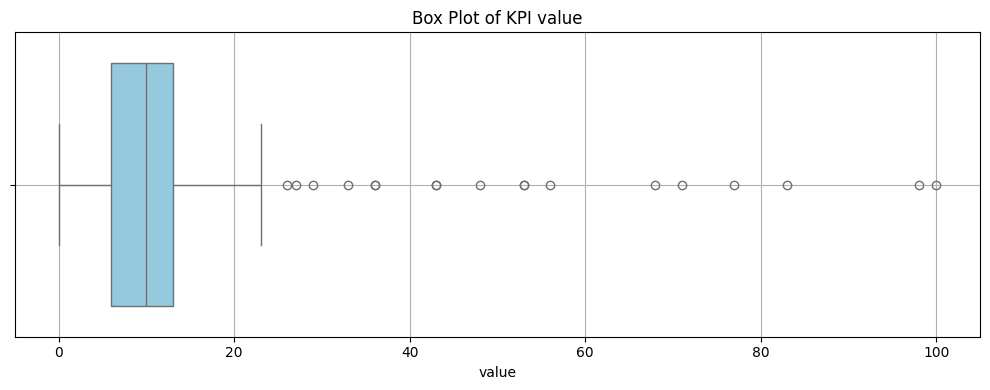

In [27]:
# ------------------------------
# 6. EDA
# ------------------------------
#Box plot
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_clean, x='value', color='skyblue')
plt.title("Box Plot of KPI value")
#plt.xlabel("KPI Value distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

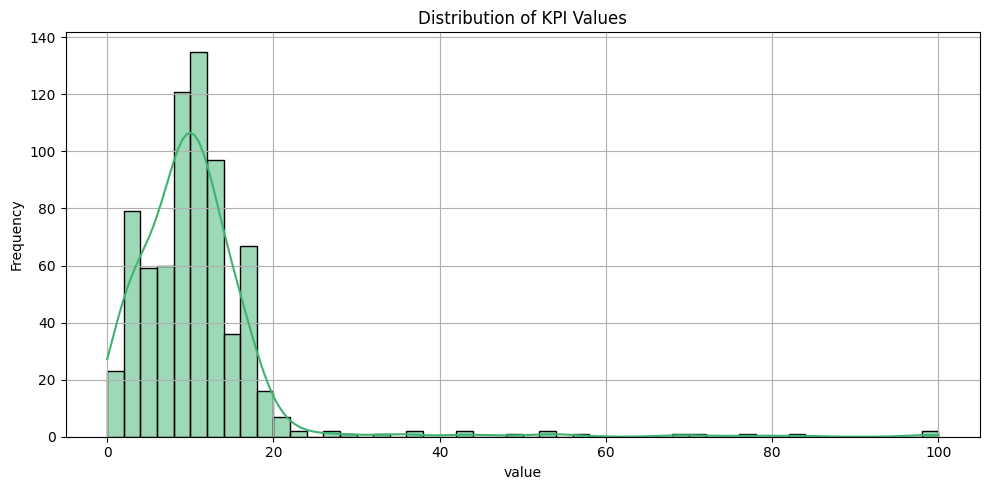

In [28]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['value'], bins=50, kde=True, color='mediumseagreen')
plt.title("Distribution of KPI Values")
#plt.xlabel("DL Throughput (Mbps)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

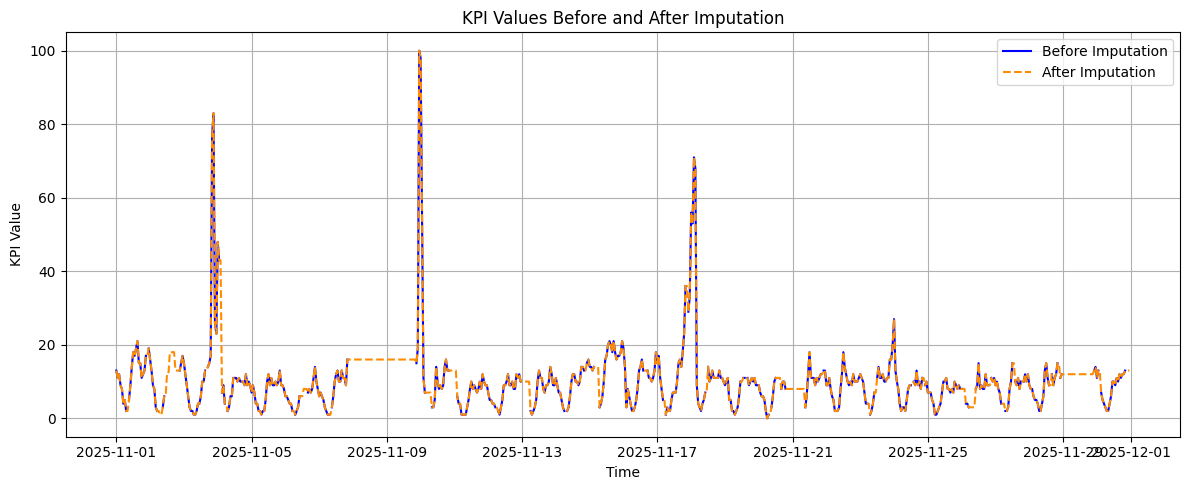

In [112]:
# ------------------------------
# PLOT BEFORE vs AFTER IMPUTATION
# ------------------------------
plt.figure(figsize=(12, 5))
plt.plot(
    df.index,
    df["value"],
    label="Before Imputation",
    linewidth=1.5,
    color='blue'
)
plt.plot(
    df_clean.index,
    df_clean["value"],
    label="After Imputation",
    linestyle="--",
    linewidth=1.5,
    color='darkorange'
)
plt.title("KPI Values Before and After Imputation")
plt.xlabel("Time")
plt.ylabel("KPI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:

# -------------------------------
# Aggregated temporal patterns
# -------------------------------
# Hourly average data
df_hourly = df_clean['value'].resample('H').mean()
# Daily average
df_daily = df_clean['value'].resample('D').mean()
# Weekly average
df_weekly = df_clean['value'].resample('W').mean()

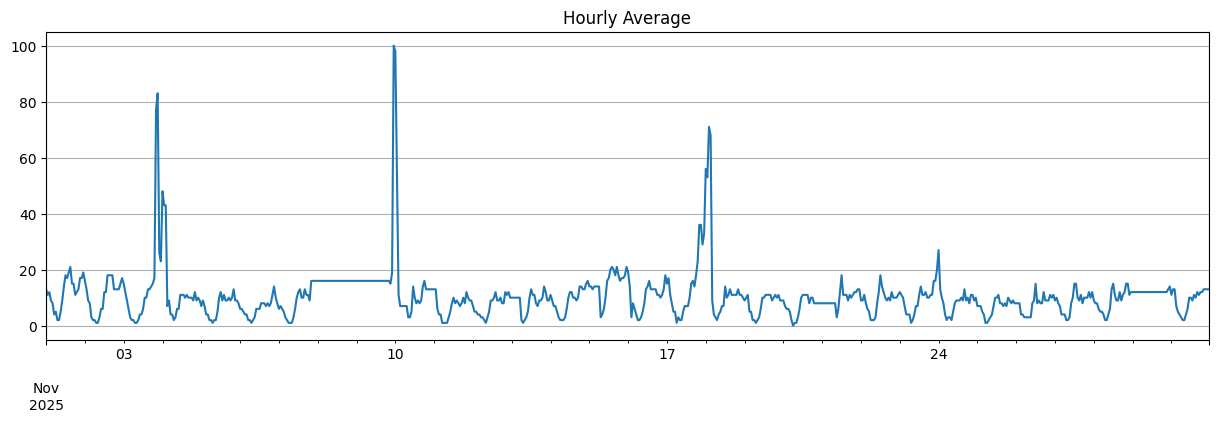

In [33]:
df_hourly.plot(title="Hourly Average", figsize=(15,4))
plt.grid(True)
plt.show()

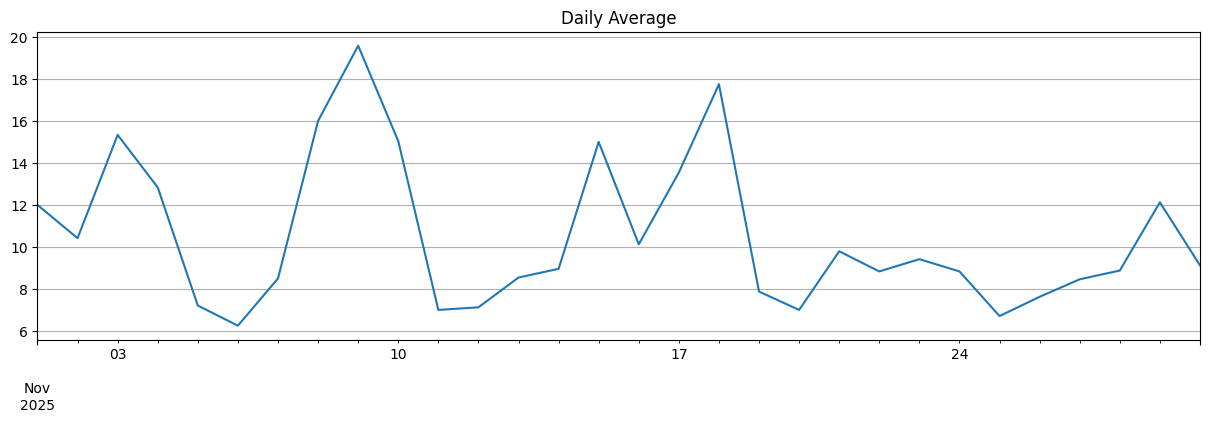

In [34]:
df_daily.plot(title="Daily Average", figsize=(15,4))
plt.grid(True)
plt.show()

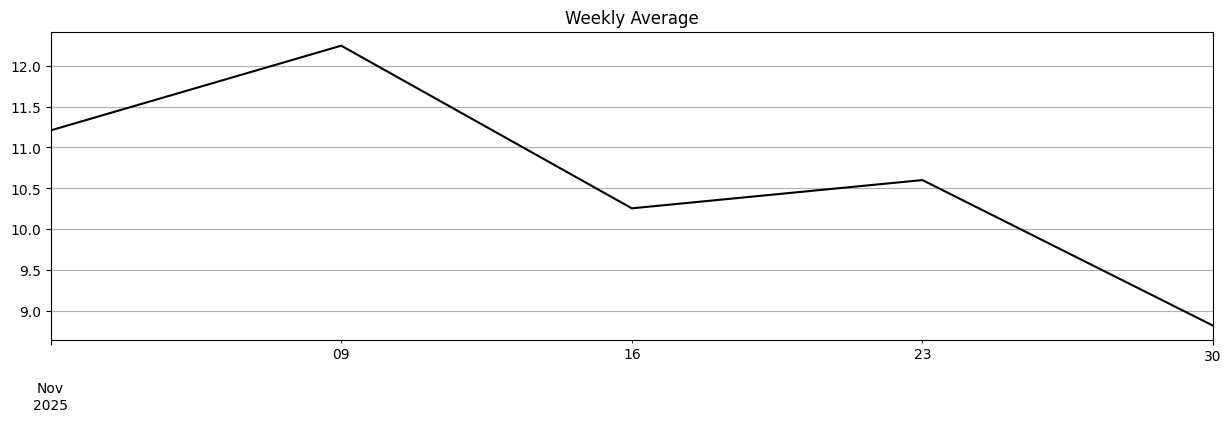

In [35]:
df_weekly.plot(title="Weekly Average", figsize=(15,4), color='black')
plt.grid(True)
plt.show()

In [36]:
# ------------------------------------------
# Plot hour-of-day day-of-the-week Patterns
# ------------------------------------------
df_clean['hour'] = df_clean.index.hour
df_clean['dayofweek'] = df_clean.index.dayofweek

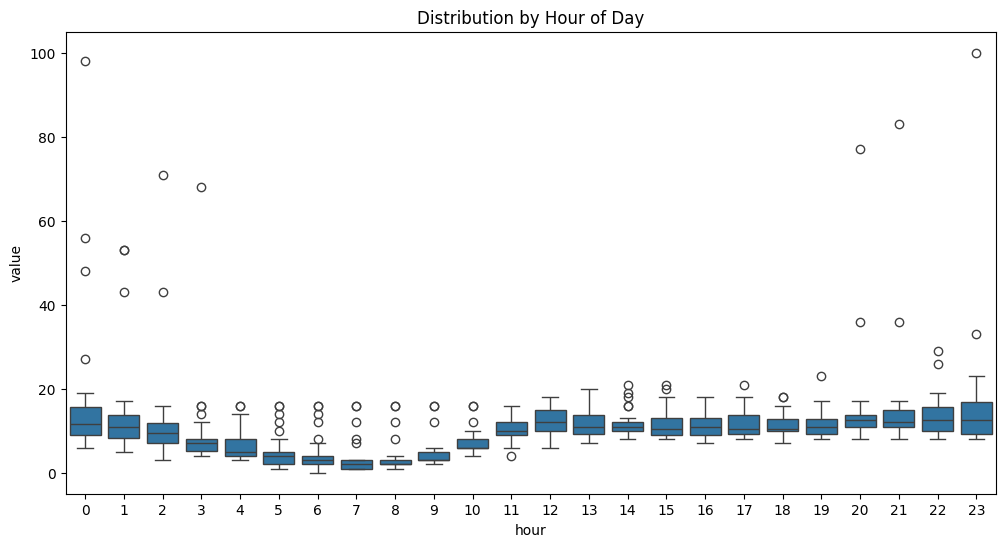

In [37]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='hour', y='value')
plt.title("Distribution by Hour of Day")
plt.show()

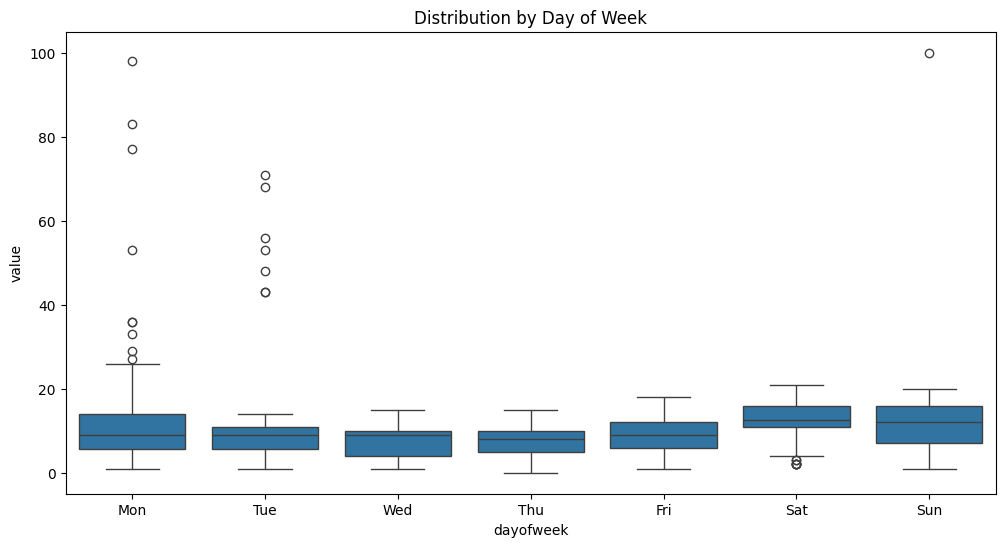

In [38]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='dayofweek', y='value')
plt.title("Distribution by Day of Week")
plt.xticks(ticks=range(7), labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.show()

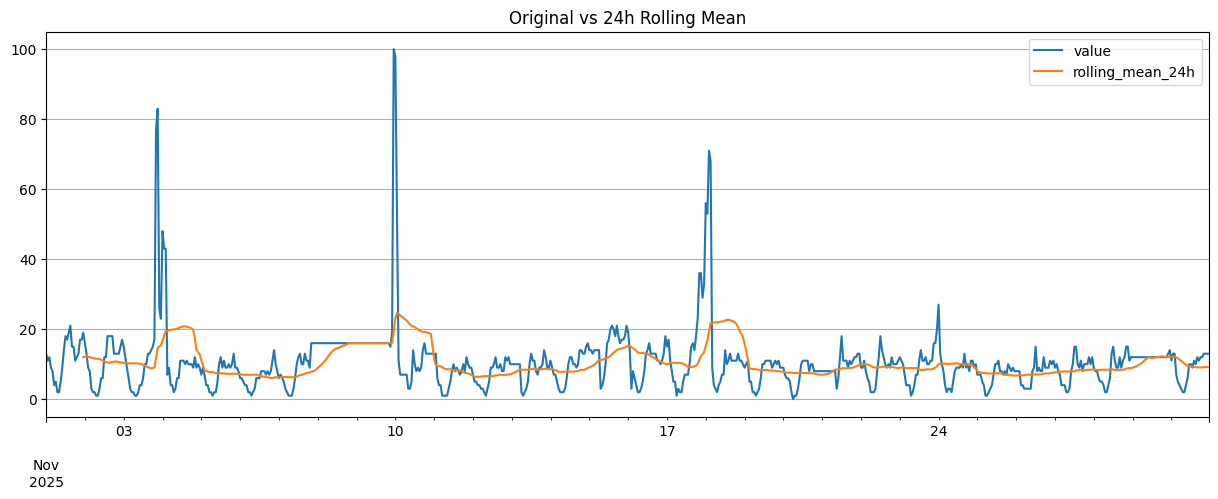

In [39]:
df_clean['rolling_mean_24h'] = df_clean['value'].rolling(window=24).mean()
df_clean[['value', 'rolling_mean_24h']].plot(figsize=(15,5), title="Original vs 24h Rolling Mean")
plt.grid(True)
plt.show()

The rolling mean plot, specifically the 'Original vs 24h Rolling Mean' plot you observed, helps to visualize the underlying trend and smooth out short-term fluctuations in the time series.

Here's the interpretation:

Smoothing Effect: The 24-hour rolling mean line is noticeably smoother than the original 'value' series. This is expected, as the rolling mean averages out the hourly variations, making the longer-term movements more apparent.
Trend Indication: The rolling mean effectively highlights the overall trend of the KPI values over the period. If the rolling mean is generally increasing, it suggests an upward trend; if decreasing, a downward trend. In this particular plot, you can observe how the KPI values fluctuate around this smoothed trend line.
Seasonality Confirmation: While the rolling mean smooths out daily seasonality, it helps to confirm the underlying pattern. If the original series consistently oscillates around the rolling mean with a fixed period, it further reinforces the presence of seasonality (which we also saw in the seasonal decomposition). The rolling mean itself might also show broader trends that are not immediately obvious in the raw, noisy data.
In essence, the rolling mean acts as a filter, separating the noise and short-term variations from the more significant, longer-term movements or trends in your KPI data.

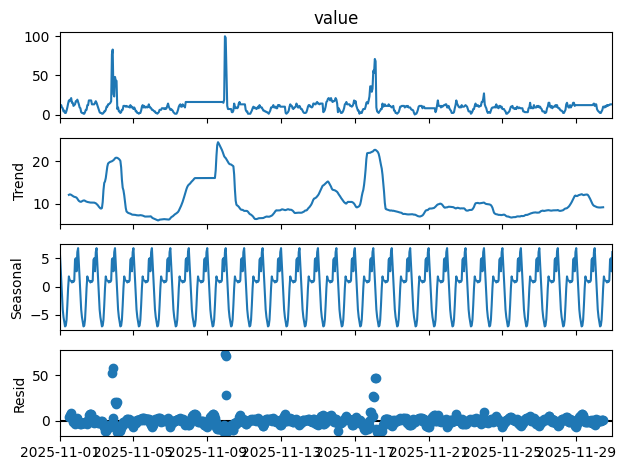

In [103]:
# ------------------------------
# 7. Seasonal Decomposition
# ------------------------------
from statsmodels.tsa.seasonal import seasonal_decompose
# Decompose into trend, seasonal, residual components
decomp = seasonal_decompose(df_clean['value'], model='additive', period=24)
decomp.plot()
plt.show()

Seasonal decomposition breaks down a time series into three main components: trend, seasonality, and residuals. For the df_clean['value'] data, as shown in the plot generated by cell 6a76a3c4, here's the interpretation:

Trend Component: This plot shows the long-term progression of the series, effectively smoothing out seasonal and irregular variations. If there's an upward slope, it indicates an increasing trend over the observed period; a downward slope indicates a decreasing trend. A relatively flat line suggests no significant long-term trend.

Seasonal Component: This component captures the repeating, cyclical patterns in the data within a fixed period (in this case, 24 hours, as specified). The plot clearly shows the average effect of each hour of the day on the KPI value, revealing how the KPI typically fluctuates within a 24-hour cycle. Peaks and troughs in this component indicate hours with consistently higher or lower KPI values.

Residual Component: Also known as the irregular or error component, this plot represents what's left after the trend and seasonal components have been removed from the original series. Ideally, the residuals should look like white noise (random, unpredictable fluctuations), indicating that the trend and seasonal components have captured most of the systematic variation in the data. Any remaining patterns in the residuals might suggest that the model hasn't fully captured all the underlying structure or that there are other unmodeled effects


In [41]:
full_residues = decomp.resid
df_clean['residues'] = full_residues
df_clean['residues'] = df_clean['residues'].dropna()

In [43]:
# ------------------------------
# ACF and PACF Plot
# ------------------------------

from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

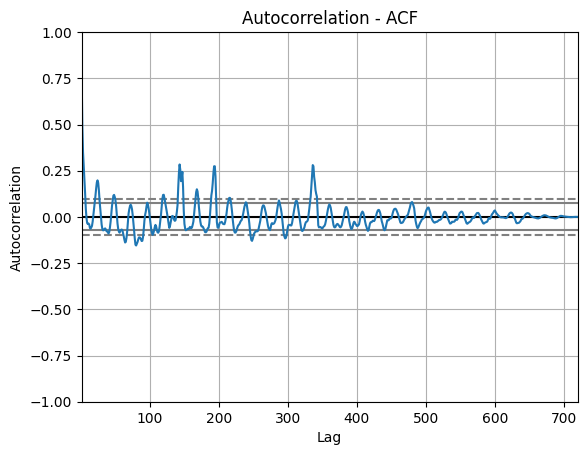

In [107]:
autocorrelation_plot(df_clean['value'])
plt.title("Autocorrelation - ACF")
plt.show()

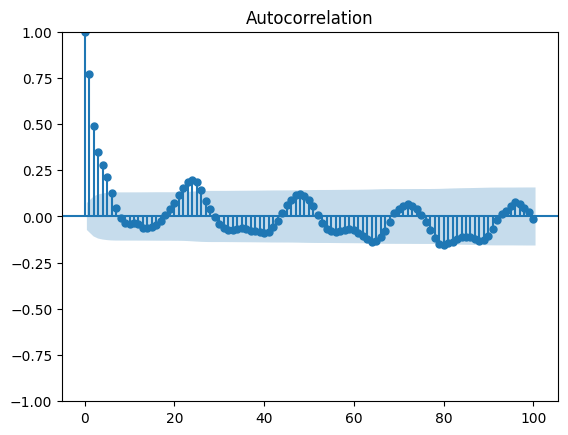

In [106]:
plot_acf(df_clean['value'], lags=100)
plt.show()

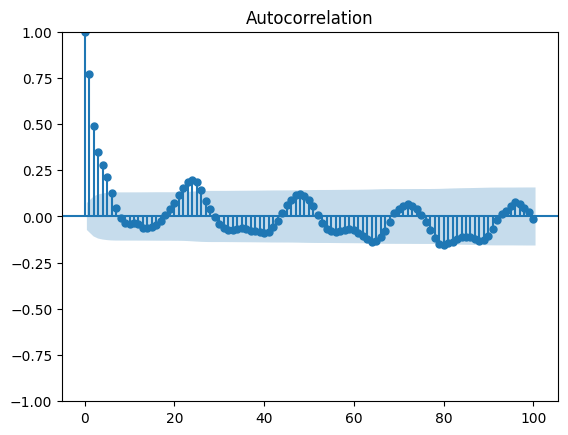

In [45]:
plot_acf(df_clean['value'], lags=100)
plt.show()

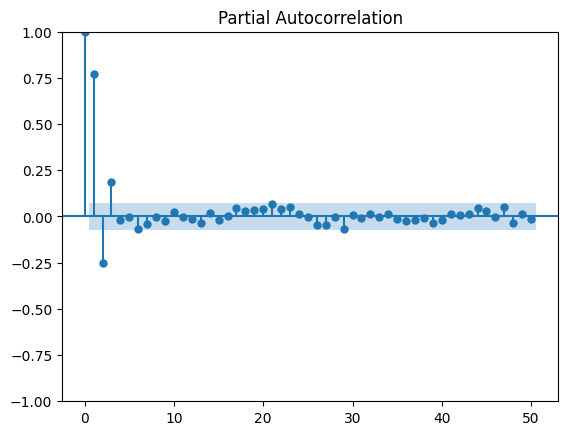

In [46]:
plot_pacf(df_clean['value'], lags=50)
plt.show()

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are crucial for understanding the dependency structure within a time series and for determining the appropriate orders for ARIMA or SARIMA models.

Here's an interpretation of what these plots generally indicate and what we observe from the generated plots for your KPI data:

Autocorrelation Function (ACF) Plot: The ACF plot shows the correlation between a time series and its lagged values. For your df_clean['value'] data, we typically see:

Slow Decay: The ACF values remain significantly high and decay slowly. This is often an indication of a non-stationary series or the presence of a strong trend and/or seasonality that has not been fully differenced out. While our stationarity tests indicated stationarity, the slow decay here is heavily influenced by the strong seasonality.
Significant Spikes at Seasonal Lags: There are prominent spikes at lags that are multiples of the seasonal period (e.g., lag 24, 48, etc.). This strongly confirms the daily seasonality in your data, meaning that the KPI value at a certain hour is highly correlated with the KPI value at the same hour on previous days. This helps in identifying the seasonal moving average (Q) and seasonal autoregressive (P) components, as well as the seasonal differencing (D) if needed.
Partial Autocorrelation Function (PACF) Plot: The PACF plot shows the direct correlation between a time series and its lagged values, with the influence of intermediate lags removed. For your data:

Significant Spikes at Seasonal Lags: Similar to the ACF, the PACF also tends to show significant spikes at seasonal lags. These direct correlations at seasonal intervals are key indicators for the seasonal autoregressive (P) component.
Cut-off or Decay for Non-Seasonal Lags: For the non-seasonal part, the PACF might show a sharp cut-off after a few lags (e.g., at lag 1 or 2), suggesting the order of the non-seasonal autoregressive (p) component. If it tails off, it could indicate a moving average process.
Lag Dependency Interpretation for Model Selection:

Non-seasonal Components (p, d, q):

p (AR order): Look for significant spikes in the PACF plot that cut off quickly. For instance, if PACF cuts off after lag 1, p=1 might be suitable.
d (Differencing order): If the ACF decays very slowly, it suggests non-stationarity, and differencing (d > 0) might be needed. However, our ADF and KPSS tests indicated stationarity, so d=0 seems appropriate for the overall series. When dealing with seasonal data, seasonal differencing (D) handles the seasonality.
q (MA order): Look for significant spikes in the ACF plot that cut off quickly. If ACF cuts off after lag 1, q=1 might be suitable.
Seasonal Components (P, D, Q, S):

S (Seasonal Period): The clear peaks at lag 24 (and its multiples) in both ACF and PACF plots firmly establish S=24 (hourly data with daily seasonality).
P (Seasonal AR order): Look for significant spikes in the PACF at seasonal lags (e.g., lag 24, 48). If there's a strong spike at lag 24 and then it cuts off or decays, P=1 could be considered.
D (Seasonal Differencing order): If the seasonal spikes in the ACF decay very slowly, it suggests seasonal non-stationarity, and seasonal differencing (D=1) might be beneficial to remove the seasonal trend. Given the strong seasonality, a D=1 is often used for hourly data.
Q (Seasonal MA order): Look for significant spikes in the ACF at seasonal lags. If there's a strong spike at lag 24 and then it cuts off or decays, Q=1 could be considered.
In summary, the ACF and PACF plots clearly highlight the strong daily seasonality and provide clues for selecting initial (p,d,q)(P,D,Q,S) orders for SARIMA models, guiding us towards considering seasonal components like (1,1,1,24) as used in some of your subsequent SARIMA models.

Based on the Exploratory Data Analysis (EDA) we performed, here are some key interpretations:

* **Distribution of KPI Values:**  The box plot and histogram show that the KPI values are generally clustered around a certain mean, but there are also some outliers present. The distribution might be slightly right-skewed, indicating a longer tail towards higher values.

Impact of Imputation: The plot comparing 'Before and After Imputation' demonstrates that missing timestamps were successfully filled, creating a continuous time series. This process appears to have smoothed out some gaps without introducing significant distortions.

Temporal Patterns: We observed clear temporal patterns:

Hourly Average: The hourly average plot likely shows a diurnal (24-hour) cycle, indicating variations in KPI values throughout the day.
Daily Average: The daily average plot reveals day-to-day fluctuations, possibly highlighting weekly cycles or other longer-term trends.

Weekly Average: The weekly average plot indicates broader trends or consistent weekly patterns.

Hour-of-Day and Day-of-Week Patterns: The box plots for 'hour' and 'dayofweek' confirm strong seasonality. KPI values tend to vary significantly depending on the hour of the day and the day of the week, suggesting predictable cycles. For instance, certain hours or days might consistently have higher or lower KPI activity.

Rolling Mean: The 24-hour rolling mean helps to smooth out short-term fluctuations and reveals the underlying trend of the KPI over time, confirming the general movement of the series.

Seasonal Decomposition: The decomposition clearly separates the original time series into its trend, seasonal, and residual components. This confirms the presence of a discernible seasonal pattern (with a period of 24 hours, as specified) and an overall trend. The residuals represent the irregular component after removing trend and seasonality.

ACF and PACF Plots: These plots are crucial for model selection. They show significant autocorrelations, especially at lags corresponding to the seasonal period (e.g., 24 hours), which is characteristic of seasonal time series. The decaying pattern of ACF and PACF helps in determining the appropriate orders (p, d, q) for ARIMA and SARIMA models. For example, a sharp drop in PACF after a few lags might suggest an AR component, while a similar drop in ACF might suggest an MA component.

In [113]:
# ------------------------------
# 8. Stationarity Tests
# ------------------------------
# Stationarity Check (ADF Test)
###
# p-value < 0.5, Reject Null Hypothesis, Accept Alternative Hypothesis
# H0 - non-stationary, H1 - Stationary
###
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_clean['value'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -8.887814168761883
p-value: 1.2661651515990732e-14


In [114]:
if result[1] < 0.05:
    print("Time series is stationary.")
else:
    print("Time series is non-stationary.")

Time series is stationary.


In [115]:
# Stationarity Check (KPSS)
###
# p-value < 0.5, Reject Null Hypothesis, Accept Alternative Hypothesis
# H0 - Stationary, H1 - Non-stationary
###

from statsmodels.tsa.stattools import kpss
kpss_result = kpss(df_clean['value'].dropna(), regression="ct", nlags="auto")

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Lags used:", kpss_result[2])
print("Critical Values:")
for key, val in kpss_result[3].items():
    print(f"   {key}: {val}")

KPSS Statistic: 0.044949514385326066
p-value: 0.1
Lags used: 14
Critical Values:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216


/tmp/ipykernel_387/304810357.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df_clean['value'].dropna(), regression="ct", nlags="auto")


In [116]:
if kpss_result[1] > 0.05:
    print("Time series is stationary.")
else:
    print("Time series is non-stationary.")

Time series is stationary.


In [117]:
# ------------------------------
# 9. ARIMA Model Training
# ------------------------------

# Since the series is stationary, d = 0

from statsmodels.tsa.arima.model import ARIMA

model_ar = ARIMA(df_clean["value"], order=(1, 0, 1))
#model_ar = ARIMA(df_clean["value"], order=(3, 0, 5))
model_ar_fit = model_ar.fit()
print(model_ar_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  720
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2256.955
Date:                Sat, 07 Mar 2026   AIC                           4521.911
Time:                        12:25:36   BIC                           4540.228
Sample:                    11-01-2025   HQIC                          4528.982
                         - 11-30-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5307      1.441      7.307      0.000       7.706      13.355
ar.L1          0.6114      0.018     34.903      0.000       0.577       0.646
ma.L1          0.4202      0.021     19.692      0.0

In [118]:
# --------------------------------
# Forecasting with order=(1, 0, 1)
# --------------------------------

forecast_horizon = 12
forecast = model_ar_fit.forecast(steps=forecast_horizon)
forecast_index = pd.date_range(
    start=df_clean.index[-1],
    periods=forecast_horizon + 1,
    freq="H"
)[1:]

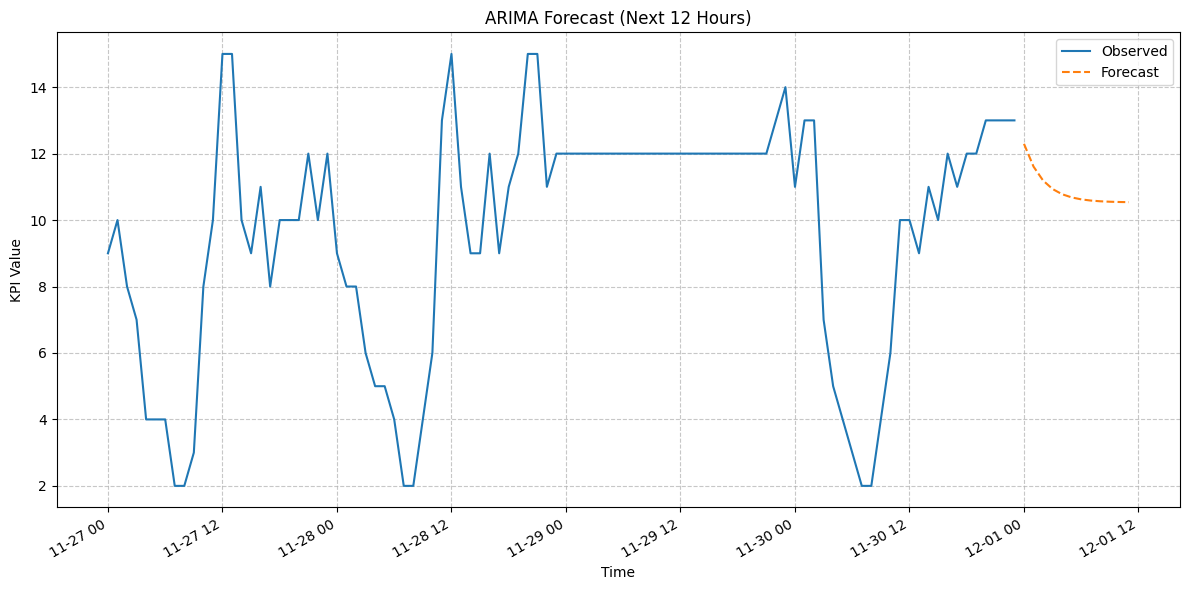

In [119]:
# ------------------------------
# Plot Forecast
# ------------------------------

plt.figure(figsize=(12,6))
#plt.plot(df_clean.index, df_clean["value"], label="Observed")
plt.plot(df_clean.index[-96:], df_clean["value"].iloc[-96:], label="Observed")
plt.plot(forecast_index, forecast, label="Forecast", linestyle="--")
plt.legend()
plt.title(f"ARIMA Forecast (Next {forecast_horizon} Hours)")
plt.xlabel("Time")
plt.ylabel("KPI Value")
plt.grid(True,linestyle="--", alpha=0.7)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [59]:
# ---------------------------------------------
# Output Multi-step Forecast Values with CI
# ---------------------------------------------

forecast_df = pd.DataFrame({
    "timestamp": forecast_index,
    "forecast_value": forecast.values
})

# plot with confidence interval
forecast_result_h = model_ar_fit.get_forecast(steps=forecast_horizon, alpha=0.05)

forecast_mean_h = forecast_result_h.predicted_mean
conf_int_h = forecast_result_h.conf_int()

# Create future timestamps
future_index_h = pd.date_range(start=df_hourly.index[-1] + pd.Timedelta(hours=1), periods=forecast_horizon, freq='H')

forecast_df_h = pd.DataFrame({
    'forecast': forecast_mean_h,
    'lower_ci': conf_int_h.iloc[:, 0],
    'upper_ci': conf_int_h.iloc[:, 1]
}, index=future_index_h)


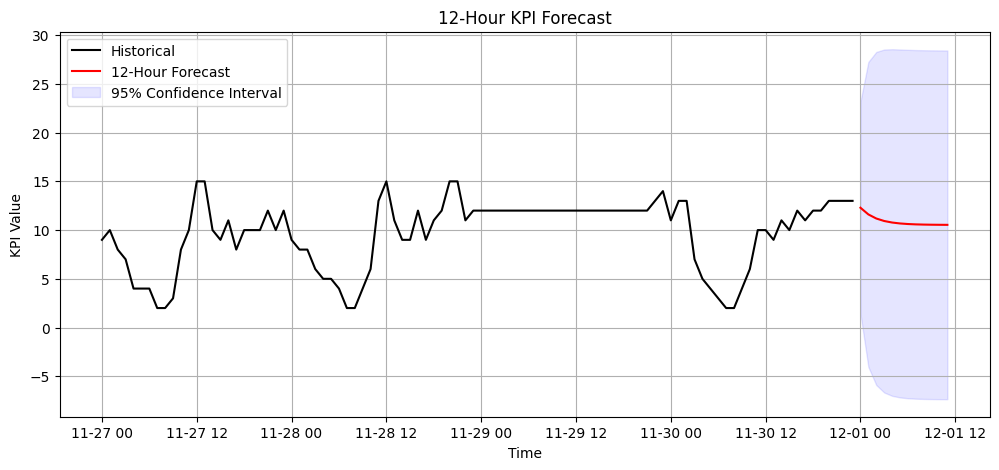

In [120]:
plt.figure(figsize=(12, 5))
plt.plot(df_hourly[-96:], label='Historical', color='black')
plt.plot(forecast_df_h.index, forecast_df_h['forecast'], label=f"{forecast_horizon}-Hour Forecast", color='red')
plt.fill_between(forecast_df_h.index,
                 forecast_df_h['lower_ci'],
                 forecast_df_h['upper_ci'],
                 color='blue', alpha=0.1, label='95% Confidence Interval')
plt.title(f"{forecast_horizon}-Hour KPI Forecast")
plt.xlabel("Time")
plt.ylabel("KPI Value")
plt.legend()
plt.grid(True)
plt.show()
#print(forecast_df_h)

MAE ARIMA: 3.1950480371509715
RMSE ARIMA: 4.1870014408281
MAPE ARIMA: 83.1724465032208


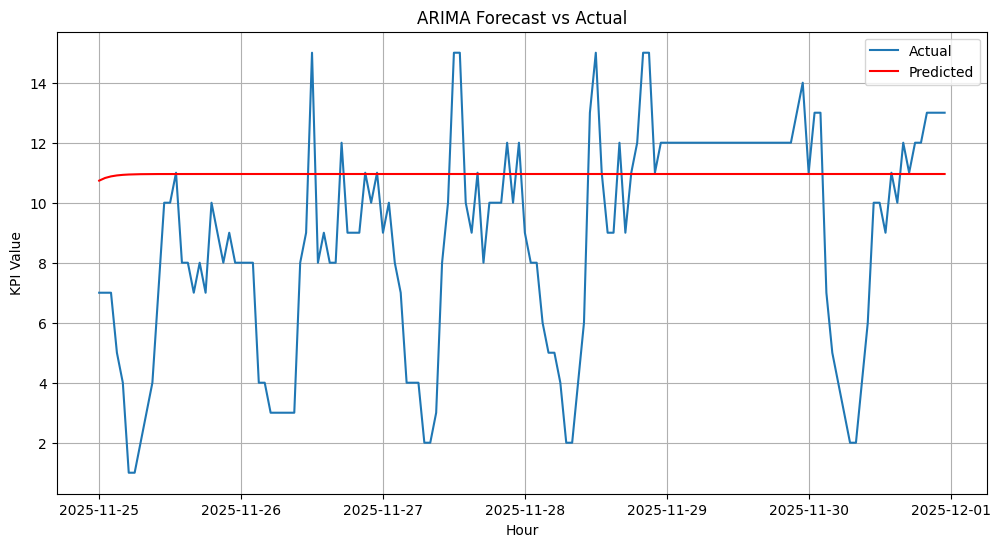

In [127]:
# Plain ARIMA on train/test split- MODEL 1

model_1 = ARIMA(train, order=(1,0,1))
model_fit_1 = model_1.fit()
model_1_forecast = model_fit_1.forecast(steps=len(test))

mae_model_1 = mean_absolute_error(test, model_1_forecast)
rmse_model_1 = np.sqrt(mean_squared_error(test, model_1_forecast))
mape_model_1 = mean_absolute_percentage_error(test, model_1_forecast) * 100

print("MAE ARIMA:", mae_model_1)
print("RMSE ARIMA:", rmse_model_1)
print("MAPE ARIMA:", mape_model_1)

plt.figure(figsize=(12,6))
#plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, model_1_forecast, label="Predicted", color='red')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Hour')
plt.ylabel('KPI Value')
plt.legend()
plt.grid(True)
plt.show()

In [128]:
# ---------------------------------------------------------------
# Multi-step Rolling Walk Froward Forecast with ARIMA - Model 2
# ---------------------------------------------------------------

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

train = []
test = []

train_size = int(len(df_hourly) * 0.8)
train, test = df_hourly[:train_size], df_hourly[train_size:]

history = train.tolist()
predictions = []
residuals = []


In [129]:
# p=3, d=0, q=5 from ACF/PACF

for t in range(len(test)):
    #model_2 = ARIMA(history, order=(3,0,5))
    model_2 = ARIMA(history, order=(1,0,1))
    model_fit_2 = model_2.fit()
    output = model_fit_2.forecast()
    predictions.append(output[0])
    history.append(test[t])
    error = test[t] - output
    residuals.append(error)

In [131]:
residuals = np.array(residuals)
mae_2 = mean_absolute_error(test, predictions)
rmse_2 = np.sqrt(mean_squared_error(test, predictions))
mape_2 = mean_absolute_percentage_error(test, predictions) * 100

In [132]:
print(f"MAE Rolling ARIMA  = {mae_2:.2f}")
print(f"RMSE Rolling ARIMA = {rmse_2:.2f}")
print(f"MAPE Rolling ARIMA = {mape_2:.2f}%")

MAE Rolling ARIMA  = 1.70
RMSE Rolling ARIMA = 2.19
MAPE Rolling ARIMA = 32.17%


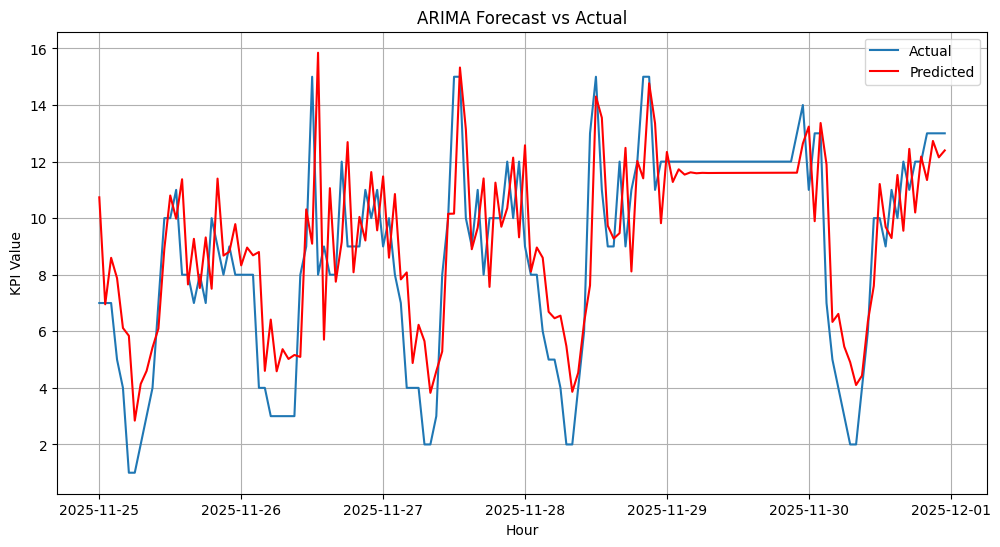

In [133]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, predictions, label='Predicted', color='red')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Hour')
plt.ylabel('KPI Value')
plt.legend()
plt.grid(True)
plt.show()

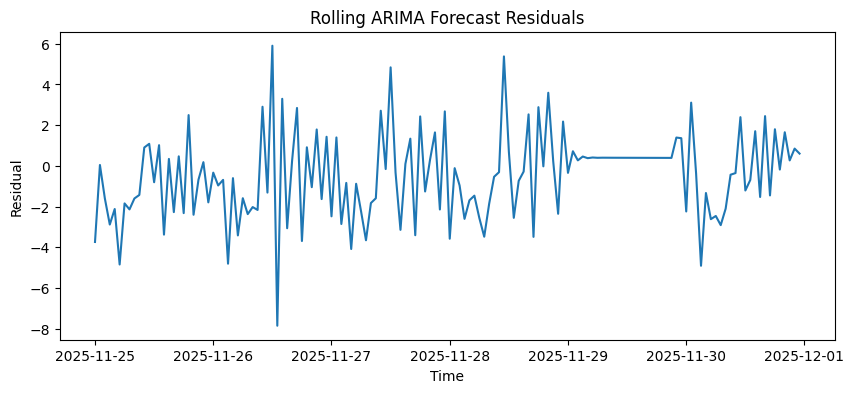

In [134]:
# ------------------------------------
# Residual time-series plot - MODEL 2
# -------------------------------------
plt.figure(figsize=(10,4))
plt.plot(test.index, residuals)
plt.title("Rolling ARIMA Forecast Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

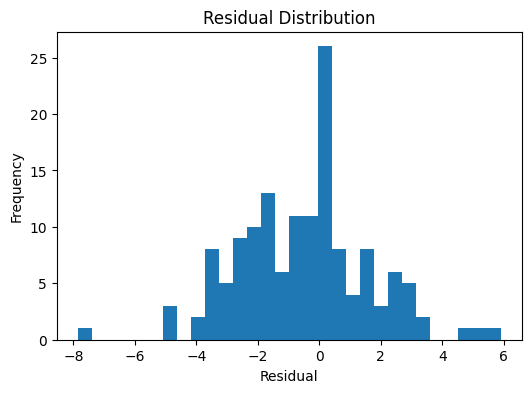

In [135]:
# ------------------------------
# Residual histogram - MODEL 2
# ------------------------------
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [122]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.1 MB/s eta 0:00:00


In [153]:
# Auto Arima wihtout Seasonality ( MODEL 3)

import pmdarima as pm

# Define the training data
train_size = int(len(df_hourly) * 0.8)
train = df_hourly[:train_size]

# Implement auto_arima
# We'll set a seasonal period of 24 for hourly data (daily seasonality)
# m=24 indicates daily seasonality since data is hourly
# D=1 indicates one seasonal differencing
# suppress_warnings=True to avoid printing warnings for failed model fits
# stepwise=True uses a stepwise algorithm to speed up the search

auto_arima_model = pm.auto_arima(train,
                                 #start_p=1, start_q=1,
                                 #test='adf', # Use ADF test to determine 'd'
                                 #max_p=3, max_q=3,
                                 seasonal=False,
                                 m=24,         # Seasonal period for hourly data (daily seasonality)
                                 #start_P=0,
                                 #d=None,       # Let auto_arima determine 'd'
                                 #D=1,          # Set seasonal differencing to 1
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

print(auto_arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=3.41 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4744.232, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3825.847, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4206.498, Time=0.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=3809.995, Time=0.34 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=3766.244, Time=0.26 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=3767.350, Time=0.41 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=3766.712, Time=0.76 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=3786.356, Time=1.11 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=1.54 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=3728.268, Time=0.39 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=3748.345, Time=0.26 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=3729.849, Time=0.38 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=3729.808, Time=0.60 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=3

In [154]:
# Make predictions on the test set using the auto_arima_model
auto_arima_forecast = auto_arima_model.predict(n_periods=len(test))

# Calculate evaluation metrics
auto_arima_mae = mean_absolute_error(test, auto_arima_forecast)
auto_arima_rmse = np.sqrt(mean_squared_error(test, auto_arima_forecast))
auto_arima_mape = mean_absolute_percentage_error(test, auto_arima_forecast) * 100

print(f"MAE ( auto_arima): {auto_arima_mae:.2f}")
print(f"RMSE ( auto_arima): {auto_arima_rmse:.2f}")
print(f"MAPE ( auto_arima): {auto_arima_mape:.2f}%")

MAE (pmdarima auto_arima): 3.19
RMSE (pmdarima auto_arima): 4.19
MAPE (pmdarima auto_arima): 83.14%


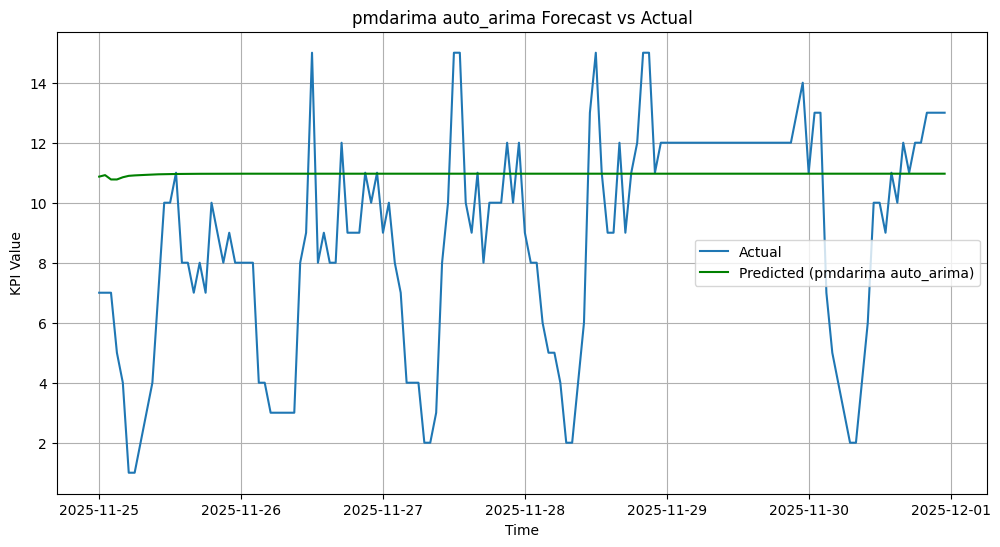

In [155]:
# Plot the forecast against actual values
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, auto_arima_forecast, label='Predicted (pmdarima auto_arima)', color='green')
plt.title('pmdarima auto_arima Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('KPI Value')
plt.legend()
plt.grid(True)
plt.show()

In [136]:
# ---------------------------------------------------------------------------
# Multi-step Rolling Forecast / ARIMA with extra steps - Model 4 ( Optional )
# ---------------------------------------------------------------------------
from statsmodels.tsa.arima.model import ARIMA

train_size = int(len(df_hourly) * 0.8)
train, test = df_hourly[:train_size], df_hourly[train_size:]

history = train.tolist()
predictions = []

extra_steps = 12
total_steps = len(test) + extra_steps

In [137]:
# Walk-forward forecast including future steps
for t in range(total_steps):
    model_4 = ARIMA(history, order=(1,0,1))
    model_fit_4 = model_4.fit()
    output = model_fit_4.forecast()
    predictions.append(output[0])

    if t < len(test):
        # For test steps, append the actual observed value
        history.append(test[t])
    else:
        # For future steps, append the forecast itself (since no actual data exists)
        history.append(output[0])

In [138]:
# Build extended index (test + 12 future hours)
future_index = pd.date_range(
    start=test.index[-1] + pd.Timedelta(hours=1),
    periods=extra_steps,
    freq="H"
)
extended_index = test.index.append(future_index)

In [139]:
mae_4 = mean_absolute_error(test, predictions[:len(predictions)-extra_steps])
rmse_4 = np.sqrt(mean_squared_error(test, predictions[:len(predictions)-extra_steps]))
mape_4 = mean_absolute_percentage_error(test, predictions[:len(predictions)-extra_steps]) * 100

In [174]:
print(f"MAE_ARIMA ( extra steps )  = {mae_4:.2f}")
print(f"RMSE_ARIMA ( extra steps ) = {rmse_4:.2f}")
print(f"MAPE_ARIMA ( extra steps ) = {mape_4:.2f}%")

NameError: name 'mae_4' is not defined

In [84]:
import matplotlib.pyplot as plt

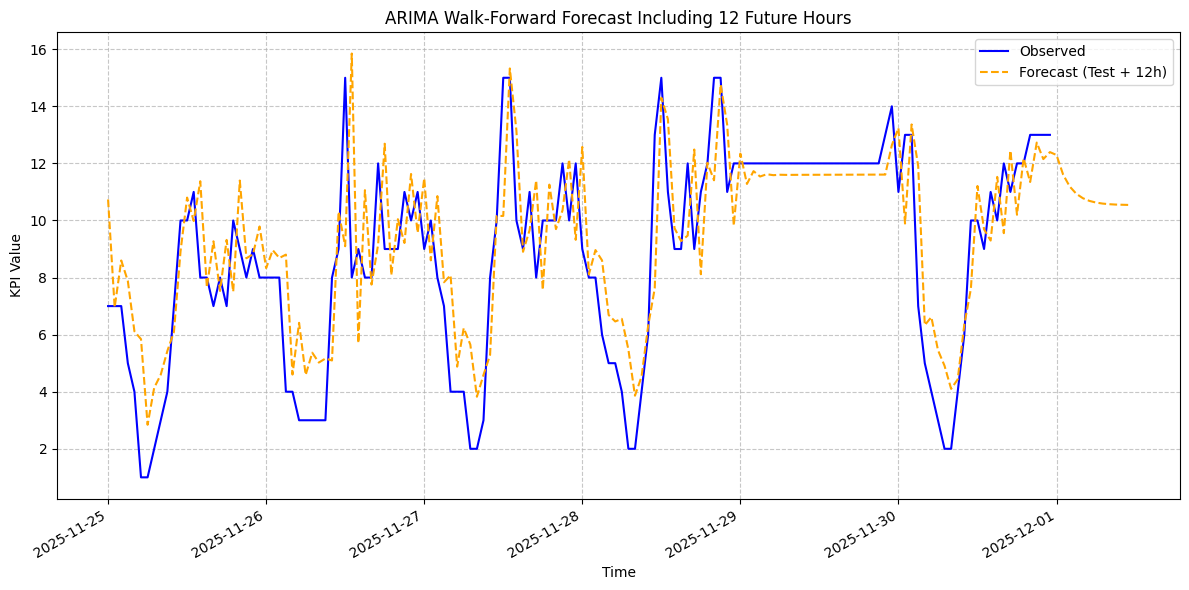

In [141]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test.values, label="Observed", color="blue")
plt.plot(extended_index, predictions, label="Forecast (Test + 12h)", linestyle="--", color="orange")
plt.legend()
plt.title("ARIMA Walk-Forward Forecast Including 12 Future Hours")
plt.xlabel("Time")
plt.ylabel("KPI Value")
plt.grid(True, linestyle="--", alpha=0.7)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [159]:
# ------------------------------------------------
# 11. SARIMA - SMODEL 1
# ------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_size = int(len(df_hourly) * 0.8)
train, test = df_hourly[:train_size], df_hourly[train_size:]


In [160]:
sar_model_1 = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    #enforce_stationarity=False,
    #enforce_invertibility=False
)

In [161]:
sar_results = sar_model_1.fit()

In [162]:
print(sar_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  576
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               -1803.143
Date:                            Sat, 07 Mar 2026   AIC                           3616.287
Time:                                    13:31:23   BIC                           3637.855
Sample:                                11-01-2025   HQIC                          3624.714
                                     - 11-24-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5551      0.018     31.062      0.000       0.520       0.590
ma.L1          0.4257      0.030   

In [163]:
sar_forecast = sar_results.forecast(steps=len(test))

In [164]:
sar_mae_1 = mean_absolute_error(test, sar_forecast)
sar_rmse_1 = np.sqrt(mean_squared_error(test, sar_forecast))
sar_mape_1 = mean_absolute_percentage_error(test, sar_forecast) * 100

In [167]:
print("MAE SARIMA M1:", sar_mae_1)
print("RMSE SARIMA M1:", sar_rmse_1)
print("MAPE SARIMA M1:", sar_mape_1)

MAE SARIMA M1: 2.993580967993198
RMSE SARIMA M1: 3.9169113549734313
MAPE SARIMA M1: 42.25587500282801


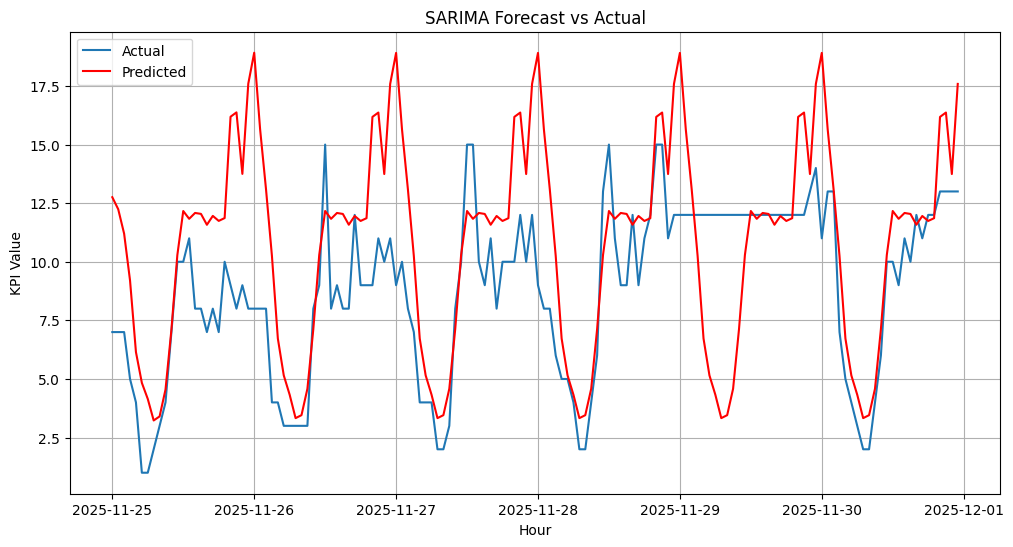

In [168]:
plt.figure(figsize=(12,6))
#plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sar_forecast, label="Predicted", color='red')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Hour')
plt.ylabel('KPI Value')
plt.legend()
plt.grid(True)
plt.show()

In [169]:
# Extract residuals
residuals = sar_results.resid

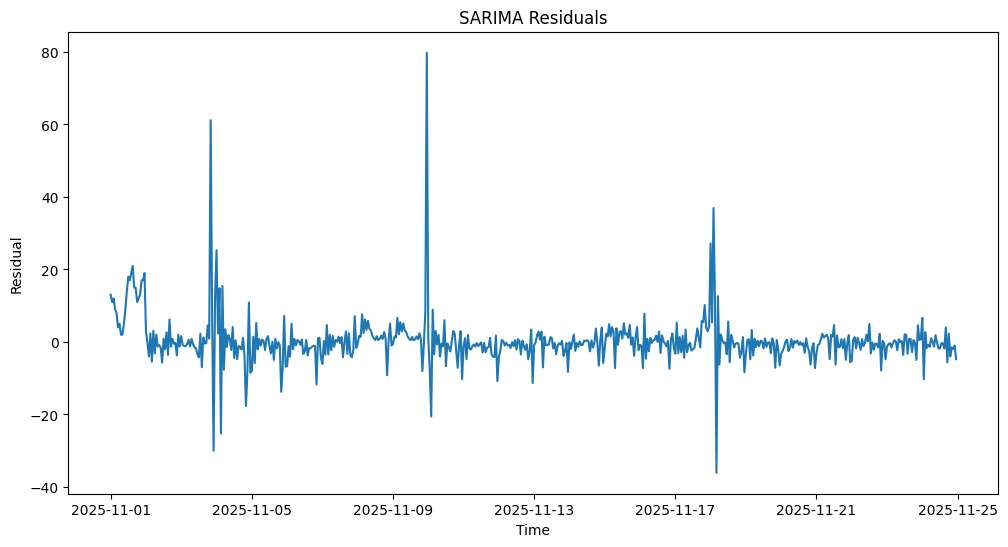

In [170]:
plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

In [171]:
# ------------------------------------------------
# SARIMA - Rolling forecast SMODEL 2
# ------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = []
test = []

train_size = int(len(df_hourly) * 0.8)
train, test = df_hourly[:train_size], df_hourly[train_size:]

In [172]:
sar_history = train.tolist()
sar_predictions = []
sar_residuals = []

In [173]:
for t in range(len(test)):
    sar_model_2 = SARIMAX(sar_history, order=(1,0,1), seasonal_order=(1,1,1,24))
    sar_model_fit_2 = sar_model_2.fit()
    sar_output = sar_model_fit_2.forecast()
    sar_predictions.append(sar_output[0])
    sar_history.append(test[t])
    sar_error = test[t] - sar_output
    sar_residuals.append(sar_error)

In [175]:
sar_residuals = np.array(sar_residuals)

In [176]:
sar_mae_2 = mean_absolute_error(test, sar_predictions)
sar_rmse_2 = np.sqrt(mean_squared_error(test, sar_predictions))
sar_mape_2 = mean_absolute_percentage_error(test, sar_predictions) * 100

In [177]:
print("MAE ( Rolling SARIMA ):", sar_mae_2)
print("RMSE ( Rolling SARIMA ):", sar_rmse_2)
print("MAPE ( Rolling SARIMA ):", sar_mape_2)

MAE ( Rolling SARIMA ): 1.7163852804023516
RMSE ( Rolling SARIMA ): 2.3006965208959427
MAPE ( Rolling SARIMA ): 22.85273184682811


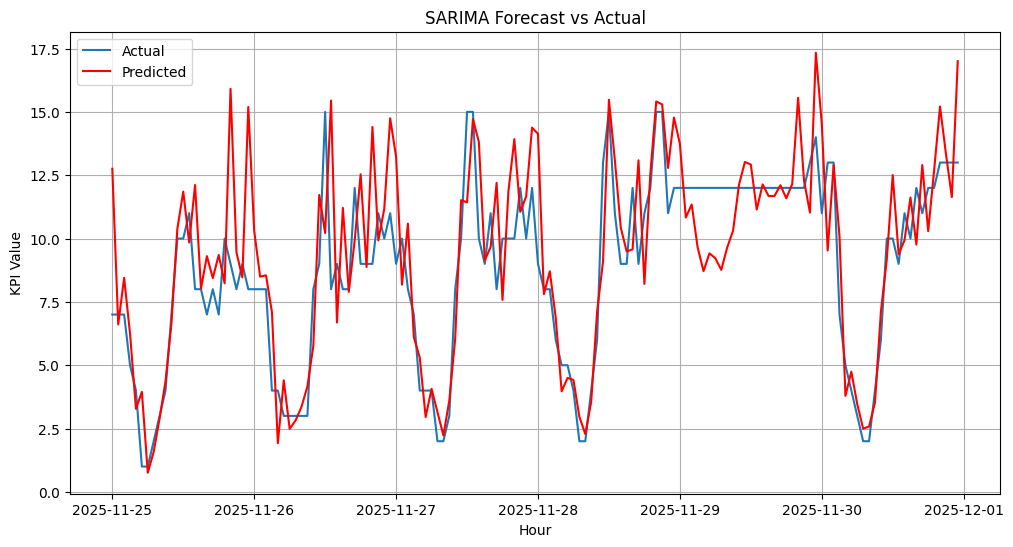

In [178]:
plt.figure(figsize=(12,6))
#plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sar_predictions, label="Predicted", color='red')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Hour')
plt.ylabel('KPI Value')
plt.legend()
plt.grid(True)
plt.show()

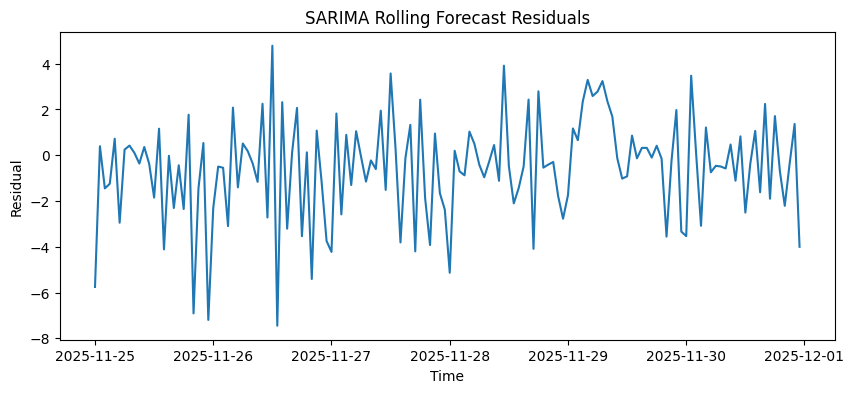

In [179]:
# ----------------------------------------
# Residual time-series plot - SMODEL 2
# -----------------------------------------
plt.figure(figsize=(10,4))
plt.plot(test.index, sar_residuals)
plt.title("SARIMA Rolling Forecast Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

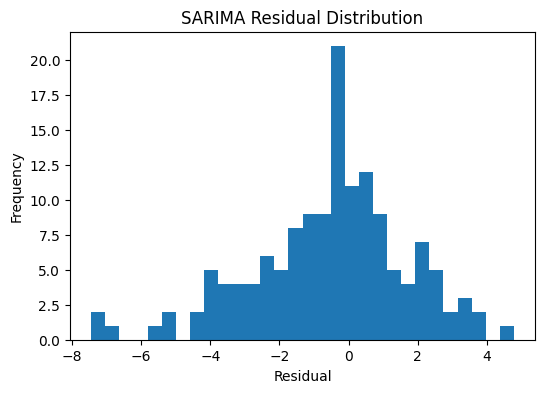

In [180]:
# --------------------------------------
# Residual histogram - SMODEL 2
# --------------------------------------
plt.figure(figsize=(6,4))
plt.hist(sar_residuals, bins=30)
plt.title("SARIMA Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [181]:
# AUTO - SARIMA with pmdarima ( SMODEL 3)

import pmdarima as pm

# Define the training data
train_size = int(len(df_hourly) * 0.8)
train = df_hourly[:train_size]

# Implement auto_arima
# We'll set a seasonal period of 24 for hourly data (daily seasonality)
# m=24 indicates daily seasonality since data is hourly
# D=1 indicates one seasonal differencing
# suppress_warnings=True to avoid printing warnings for failed model fits
# stepwise=True uses a stepwise algorithm to speed up the search

auto_sarima_model = pm.auto_arima(train,
                                 start_p=1, start_q=1,
                                 test='adf', # Use ADF test to determine 'd'
                                 max_p=3, max_q=3,
                                 seasonal=True,
                                 m=24,         # Seasonal period for hourly data (daily seasonality)
                                 start_P=0,
                                 D=1,          # Set seasonal differencing to 1
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

print(auto_sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[24] intercept   : AIC=inf, Time=13.31 sec
 ARIMA(0,0,0)(0,1,0)[24] intercept   : AIC=4402.789, Time=0.13 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : AIC=3850.488, Time=3.19 sec
 ARIMA(0,0,1)(0,1,1)[24] intercept   : AIC=inf, Time=10.58 sec
 ARIMA(0,0,0)(0,1,0)[24]             : AIC=4400.851, Time=0.21 sec
 ARIMA(1,0,0)(0,1,0)[24] intercept   : AIC=3988.298, Time=0.62 sec
 ARIMA(1,0,0)(2,1,0)[24] intercept   : AIC=3786.299, Time=15.43 sec
 ARIMA(1,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=49.85 sec
 ARIMA(1,0,0)(1,1,1)[24] intercept   : AIC=inf, Time=14.08 sec
 ARIMA(0,0,0)(2,1,0)[24] intercept   : AIC=4236.345, Time=14.87 sec
 ARIMA(2,0,0)(2,1,0)[24] intercept   : AIC=3753.803, Time=20.89 sec
 ARIMA(2,0,0)(1,1,0)[24] intercept   : AIC=3819.740, Time=3.69 sec
 ARIMA(2,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=50.01 sec
 ARIMA(2,0,0)(1,1,1)[24] intercept   : AIC=inf, Time=17.23 sec
 ARIMA(3,0,0)(2,1,0)[24] intercept   : A

In [182]:
# Make predictions on the test set using the auto_arima_model
auto_sarima_forecast = auto_sarima_model.predict(n_periods=len(test))

# Calculate evaluation metrics
auto_sarima_mae = mean_absolute_error(test, auto_sarima_forecast)
auto_sarima_rmse = np.sqrt(mean_squared_error(test, auto_sarima_forecast))
auto_sarima_mape = mean_absolute_percentage_error(test, auto_sarima_forecast) * 100

print(f"MAE (auto_sarima): {auto_sarima_mae:.2f}")
print(f"RMSE (auto_sarima): {auto_sarima_rmse:.2f}")
print(f"MAPE (auto_sarima): {auto_sarima_mape:.2f}%")

MAE (auto_sarima): 2.08
RMSE (auto_sarima): 3.06
MAPE (auto_sarima): 25.28%


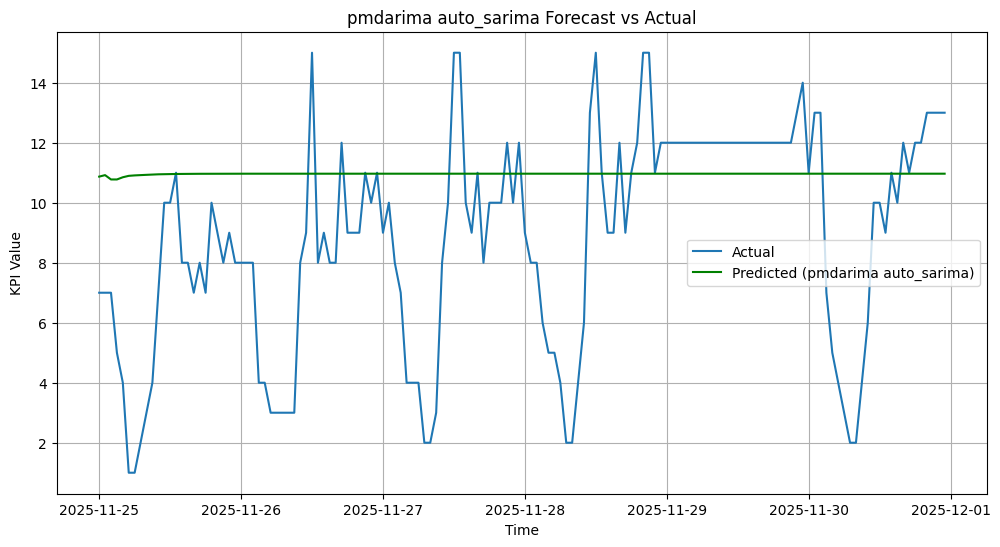

In [183]:
# Plot the forecast against actual values
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, auto_arima_forecast, label='Predicted (pmdarima auto_sarima)', color='green')
plt.title('pmdarima auto_sarima Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('KPI Value')
plt.legend()
plt.grid(True)
plt.show()

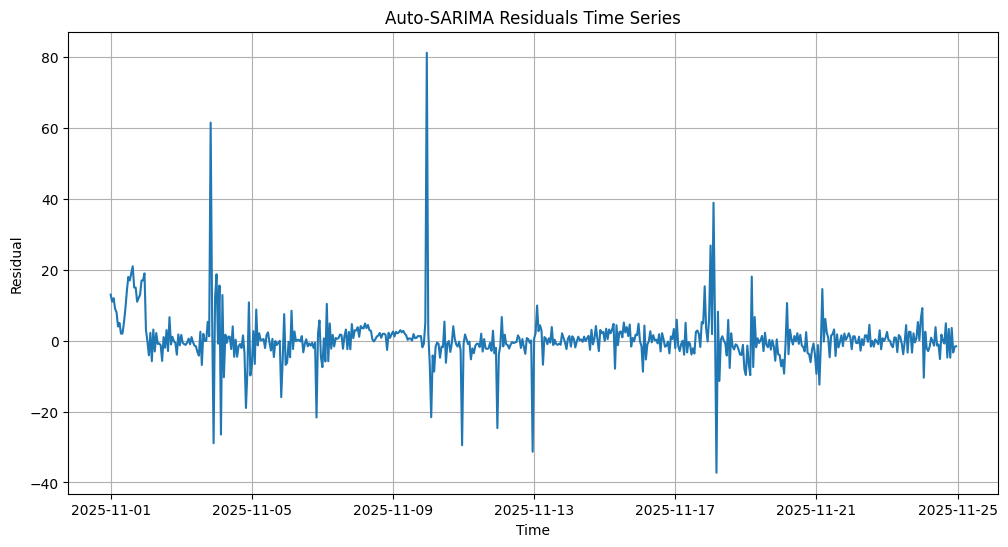

In [184]:
# Extract residuals from the auto_sarima_model
auto_sarima_residuals = auto_sarima_model.resid()

# Plot Residual time-series
plt.figure(figsize=(12, 6))
plt.plot(auto_sarima_residuals)
plt.title("Auto-SARIMA Residuals Time Series")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

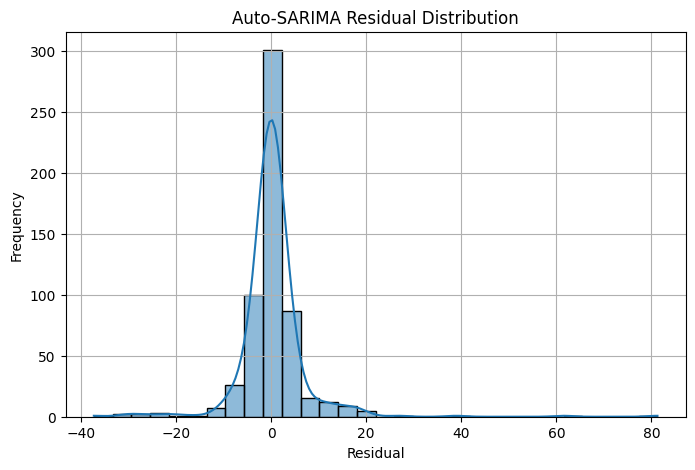

In [185]:
# Plot Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(auto_sarima_residuals, bins=30, kde=True)
plt.title("Auto-SARIMA Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<Figure size 1200x600 with 0 Axes>

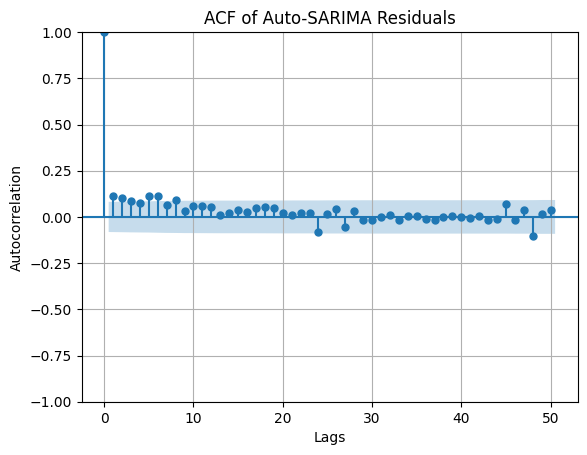

In [186]:
# Generate ACF plot for the residuals
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 6))
plot_acf(auto_sarima_residuals, lags=50)
plt.title("ACF of Auto-SARIMA Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

In [142]:
# ------------------------------------------------------------
# 12. Manual Auto ARIMA (Grid Search with statsmodels, OPTIONAL)
# ------------------------------------------------------------

def auto_arima_manual(ts, p_range=3, d_range=1, q_range=3):
    best_aic = np.inf
    best_order = None
    best_model = None

    for p in range(p_range + 1):
        for d in range(d_range + 1):
            for q in range(q_range + 1):
                try:
                    model = ARIMA(ts, order=(p, d, q)).fit()
                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_order = (p, d, q)
                        best_model = model
                except(ValueError, np.linalg.LinAlgError):
                    continue

    print(f"Best ARIMA order: {best_order} with AIC: {best_aic:.2f}")
    return best_model, best_order, best_aic

In [143]:
best_model_h, best_order_h, best_aic_h = auto_arima_manual(df_hourly)
##best_model_d, best_order_d, best_aic_d = auto_arima_manual(df_daily)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order: (3, 1, 1) with AIC: 4517.89


In [144]:
# Forecast for 24 hours with auto-arima
forecast_result_h = best_model_h.get_forecast(steps=24, alpha=0.05)

In [145]:
forecast_mean_h = forecast_result_h.predicted_mean
conf_int_h = forecast_result_h.conf_int()

In [146]:
# Create future timestamps
future_index_h = pd.date_range(start=df_hourly.index[-1] + pd.Timedelta(hours=1), periods=24, freq='H')

In [147]:
forecast_df_h = pd.DataFrame({
    'forecast': forecast_mean_h,
    'lower_ci': conf_int_h.iloc[:, 0],
    'upper_ci': conf_int_h.iloc[:, 1]
}, index=future_index_h)

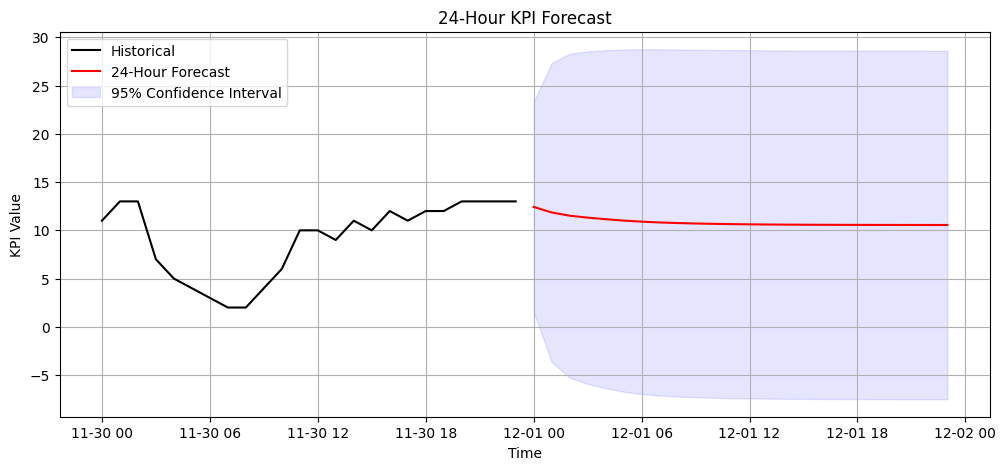

In [150]:
plt.figure(figsize=(12, 5))
plt.plot(df_hourly[-24:], label='Historical', color='black')
plt.plot(forecast_df_h.index, forecast_df_h['forecast'], label='24-Hour Forecast', color='red')
plt.fill_between(forecast_df_h.index,
                 forecast_df_h['lower_ci'],
                 forecast_df_h['upper_ci'],
                 color='blue', alpha=0.1, label='95% Confidence Interval')
plt.title("24-Hour KPI Forecast")
plt.xlabel("Time")
plt.ylabel("KPI Value")
plt.legend()
plt.grid(True)
plt.show()

###### ====================*****************================****************==================*************** #######

Performance Comparison - ARIMA

1. Model 1: Plain ARIMA (Train/Test Split)

Description: This is a simple ARIMA(1,0,1) model trained once on the initial train dataset and then used to forecast the entire test set without any further retraining.
Order Used: ARIMA(1,0,1)
Performance Metrics:
MAE ARIMA: 3.20
RMSE ARIMA: 4.19
MAPE ARIMA: 83.17%

Interpretation: This model showed very poor performance. The high MAPE clearly indicates its inability to capture the underlying patterns, especially the strong daily seasonality. Since it's trained only once, it cannot adapt to any new information or evolving trends in the data.

2. Model 2: Multi-step Rolling Walk-Forward ARIMA

Description: This model also uses an ARIMA(1,0,1) order, but it employs a rolling walk-forward validation strategy. For each step in the test set, it forecasts the next single point, incorporates the actual observed value into its training history, and then retrains before forecasting the next point.
Order Used: ARIMA(1,0,1)
Performance Metrics:
MAE Rolling ARIMA: 1.70
RMSE Rolling ARIMA: 2.19
MAPE Rolling ARIMA: 32.17%

Interpretation: The performance of this model is significantly better than Model 1. The improvement is attributed to the rolling walk-forward approach. By constantly retraining with the most recent observed data, the model gains an adaptive advantage, allowing it to capture some of the time-varying characteristics of the series, even though its core ARIMA(1,0,1) structure doesn't explicitly model seasonality.

3. MODEL 3:  Auto-ARIMA (Non-Seasonal)

Description: This model was automatically selected by the pmdarima.auto_arima function, but with the seasonal=False parameter, meaning it was constrained to find the best non-seasonal ARIMA model. The best model found was ARIMA(3,0,0).
Order Used: ARIMA(3,0,0)
Performance Metrics:
MAE (pmdarima auto_arima): 3.19
RMSE (pmdarima auto_arima): 4.19
MAPE (pmdarima auto_arima): 83.14%

Interpretation: Despite pmdarima's advanced search capabilities, its performance was similar to Model 1 (the simple static ARIMA). This result confirms that when seasonality is explicitly ignored (by setting seasonal=False), even an optimized non-seasonal ARIMA model will struggle to accurately forecast data with strong seasonal patterns. The model might have a higher non-seasonal autoregressive order (p=3) compared to Model 1's p=1, but without addressing seasonality, the overall predictive power remains low.

Performance Comparison Summary
Model	MAE	RMSE	MAPE
1. Plain ARIMA (Static Train/Test)	3.20	4.19	83.17%
2. Rolling Walk-Forward ARIMA	1.70	2.19	32.17%
3. pmdarima Auto-ARIMA (Non-Seasonal)	3.19	4.19	83.14%


Key Insights from this Comparison:

Impact of Rolling Forecast: The most striking difference is the superior performance of Model 2 (Rolling Walk-Forward ARIMA). This highlights that for time series data, constantly updating the model with new observations is often more crucial than the specific, fixed non-seasonal ARIMA order when strong seasonality is not explicitly modeled.

Importance of Seasonality: Both Model 1 and the non-seasonal pmdarima auto-ARIMA (Model 3) performed poorly because they did not account for the pronounced daily seasonality in the data. Their MAPE values are very high, indicating that they consistently miss the periodic fluctuations.

Limitations of Non-Seasonal Models: Even pmdarima couldn't find a significantly better model when restricted to non-seasonal parameters for this dataset, underscoring that for seasonal data, seasonal modeling (e.g., SARIMA) is indispensable.

Let's compare the performance of the three SARIMA models you've implemented, along with key insights and limitations:

1. SARIMA - SMODEL 1 (Static Train/Test Split)

Description: This model (SARIMAX(1, 0, 1)x(1, 1, 1, 24)) was trained once on the initial train dataset and then used to forecast the entire test set without any further retraining. The parameters were manually chosen.

Order Used: (1,0,1)(1,1,1,24)

Performance Metrics:
MAE: 2.99
RMSE: 3.92
MAPE: 42.26%

Key Insights & Limitations: While significantly better than the non-seasonal ARIMA models, its performance is still limited by the static training approach. It captures seasonality (as evidenced by a lower MAPE compared to non-seasonal ARIMA), but its fixed nature prevents it from adapting to new information or subtle shifts in the time series dynamics over the forecast horizon. The manually selected parameters might not be truly optimal.

2. SARIMA - Rolling Forecast SMODEL 2

Description: This model (SARIMAX(1,0,1)x(1,1,1,24)) employs a rolling walk-forward validation strategy. For each step in the test set, it forecasts the next single point, incorporates the actual observed value into its training history, and then retrains before forecasting the next point. The parameters were manually chosen.

Order Used: (1,0,1)(1,1,1,24)

Performance Metrics:
MAE: 1.72
RMSE: 2.30
MAPE: 22.85%

Key Insights & Limitations: This model demonstrates the most significant improvement, achieving the lowest MAE, RMSE, and MAPE among all models tested so far. The rolling walk-forward approach allows the model to continuously learn from the most recent data, making its forecasts highly adaptive. This is crucial for capturing evolving patterns in real-world time series. Its limitation lies in the computational cost of retraining at every step, and the fact that its parameters were still manually chosen.

3. AUTO - SARIMA with pmdarima (SMODEL 3)

Description: This model was automatically selected by the pmdarima.auto_arima function (with seasonal=True) to find the best SARIMA parameters based on minimizing AIC. It was trained once on the train set and then used to forecast the entire test set.

Order Used: SARIMAX(3, 0, 0)x(2, 1, 0, 24) (non-seasonal AR(3), seasonal AR(2) with 1 seasonal differencing, period 24)

Performance Metrics:
MAE: 2.08
RMSE: 3.06
MAPE: 25.28%

Key Insights & Limitations: This model provides a robust solution by automatically identifying optimal SARIMA orders. Its performance is notably better than the static SARIMA M1 but not as good as the rolling SARIMA SMODEL 2. This suggests that while pmdarima finds good parameters, the strategy of forecasting (static vs. rolling) plays a huge role. Its strength is in automating parameter selection, but its static application (training once) limits its adaptiveness compared to a rolling forecast.

Performance Comparison Summary - SARIMA Models
Model	MAE	RMSE	MAPE
1. SARIMA SMODEL 1 (Static)	2.99	3.92	42.26%
2. SARIMA SMODEL 2 (Rolling)	1.72	2.30	22.85%
3. AUTO-SARIMA SMODEL 3 (pmdarima)	2.08	3.06	25.28%
Overall Conclusion:

The SARIMA Rolling Forecast (SMODEL 2) clearly outperforms the other models, indicating that for your KPI time series, continuously updating the model with new observations is the most critical factor for accurate forecasting. Even with potentially non-optimal manually chosen SARIMA parameters, the adaptive nature of the rolling forecast significantly boosts performance.

The AUTO-SARIMA SMODEL 3 is a strong second, demonstrating the power of automated parameter tuning to find a good model structure. If computational resources or time constraints prevent constant retraining, this model provides a good balance between automation and performance.

The SARIMA SMODEL 1 (Static), while acknowledging seasonality, still suffers from its inability to adapt to real-time data, similar to its non-seasonal ARIMA counterpart. This underscores that a good model structure is only part of the solution; an effective forecasting strategy is equally important.

### **Consolidated Performance Comparison of All Models**

| Model                                           | MAE  | RMSE | MAPE   |
| :---------------------------------------------- | :--- | :--- | :----- |
| **ARIMA Models**                                |      |      |        |
| 1. Plain ARIMA (Static Train/Test)              | 3.20 | 4.19 | 83.17% |
| 2. Rolling Walk-Forward ARIMA                   | 1.70 | 2.19 | 32.17% |
| 3. pmdarima Auto-ARIMA (Non-Seasonal)           | 3.19 | 4.19 | 83.14% |
| **SARIMA Models**                               |      |      |        |
| 1. SARIMA SMODEL 1 (Static)                     | 2.99 | 3.92 | 42.26% |
| 2. SARIMA SMODEL 2 (Rolling)                    | 1.72 | 2.30 | 22.85% |
| 3. AUTO-SARIMA SMODEL 3 (pmdarima)              | 2.08 | 3.06 | 25.28% |
